<a href="https://colab.research.google.com/github/DanielYaari28/AIPI510P1/blob/daniel-feature-engineering/02_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/DanielYaari28/AIPI510P1/refs/heads/daniel-feature-engineering/data/cleaned_college_data.csv"

df = pd.read_csv(url)

In [5]:
df.shape

(807, 15)

In [6]:
df.columns

Index(['UNITID', 'INSTNM', 'STABBR', 'CONTROL', 'UGDS', 'C150_4', 'RET_FT4',
       'NPT4_PUB', 'NPT4_PRIV', 'DEBT_MDN', 'COSTT4_A', 'MD_EARN_WNE_P10',
       'PCTPELL', 'ADM_RATE', 'NET_PRICE'],
      dtype='object')

In [7]:
#Cat 1: Student Success
df["STUDENT_SUCCESS"] = df["RET_FT4"] * 0.3 + df["C150_4"] * 0.7

In [8]:
df.sort_values("STUDENT_SUCCESS", ascending=False)

,UNITID,INSTNM,STABBR,CONTROL,UGDS,C150_4,RET_FT4,NPT4_PUB,NPT4_PRIV,DEBT_MDN,COSTT4_A,MD_EARN_WNE_P10,PCTPELL,ADM_RATE,NET_PRICE,STUDENT_SUCCESS
393,186131,Princeton University,NJ,2,5709.0,0.9761,0.9835,NaN,6128.0,10000.0,84040.0,110066.0,0.1924,0.0462,6128.0,0.97832
286,166027,Harvard University,MA,2,7601.0,0.9758,0.9830,NaN,19066.0,12500.0,85540.0,101817.0,0.1643,0.0365,19066.0,0.97796
577,215062,University of Pennsylvania,PA,2,10650.0,0.9654,0.9888,NaN,28699.0,14000.0,89028.0,111371.0,0.1653,0.0540,28699.0,0.97242
292,166683,Massachusetts Institute of Technology,MA,2,4535.0,0.9641,0.9908,NaN,20111.0,12462.0,82730.0,143372.0,0.1932,0.0455,20111.0,0.97211
481,198419,Duke University,NC,2,6442.0,0.9678,0.9793,NaN,29612.0,12000.0,87072.0,97800.0,0.1403,0.0571,29612.0,0.97125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,154022,The University of Arizona Global Campus,AZ,1,20152.0,0.1068,0.3473,NaN,31266.0,9500.0,37594.0,35404.0,0.3207,NaN,31266.0,0.17895
779,445027,American InterContinental University System,AZ,3,7111.0,0.0851,0.3596,NaN,15172.0,9500.0,22256.0,36144.0,0.7100,NaN,15172.0,0.16745
781,445267,Central Methodist University-College of Gradua...,MO,2,2092.0,0.0000,0.5294,NaN,14601.0,13292.0,22310.0,48991.0,0.3188,0.8753,14601.0,0.15882
792,460349,Johnson & Wales University-Online,RI,2,2202.0,0.0000,0.5217,NaN,20252.0,16334.0,26864.0,43418.0,0.3623,0.9097,20252.0,0.15651


In [9]:
student_success = (
    df
    .sort_values("STUDENT_SUCCESS", ascending=False)
    .head(10)
    [["INSTNM", "C150_4", "RET_FT4", "STUDENT_SUCCESS"]]
)

student_success

,INSTNM,C150_4,RET_FT4,STUDENT_SUCCESS
393,Princeton University,0.9761,0.9835,0.97832
286,Harvard University,0.9758,0.9830,0.97796
577,University of Pennsylvania,0.9654,0.9888,0.97242
292,Massachusetts Institute of Technology,0.9641,0.9908,0.97211
481,Duke University,0.9678,0.9793,0.97125
172,University of Chicago,0.9585,0.9926,0.96873
414,Columbia University in the City of New York,0.9610,0.9800,0.96670
101,Yale University,0.9574,0.9878,0.96652
592,Brown University,0.9569,0.9882,0.96629
380,Dartmouth College,0.9554,0.9842,0.96404


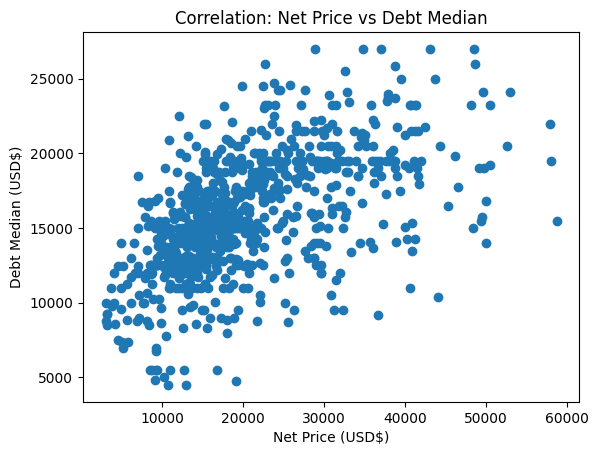

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["NET_PRICE"], df["DEBT_MDN"])
plt.xlabel("Net Price (USD$)")
plt.ylabel("Debt Median (USD$)")
plt.title("Correlation: Net Price vs Debt Median")
plt.show()

In [11]:
r = df["NET_PRICE"].corr(df["DEBT_MDN"])
print(r)

0.5578354517886546


R^2=0.5582=0.31

About 31% of the variation is associated with their linear relationship.
They're related, but they're not measuring the exact same thing.

In [12]:
df["DEBT_TO_EARNINGS"] = (df["DEBT_MDN"] / df["MD_EARN_WNE_P10"])

df["DEBT_TO_EARNINGS"]

,DEBT_TO_EARNINGS
0,0.408585
1,0.290490
2,0.225120
3,0.507217
4,0.303710
...,...
802,0.477512
803,0.269692
804,0.265472
805,0.372024


In [13]:
outcome = (
    df.sort_values("DEBT_TO_EARNINGS", ascending=True).head(10)
    [["INSTNM", "DEBT_MDN", "MD_EARN_WNE_P10", "DEBT_TO_EARNINGS"]]
)

outcome

,INSTNM,DEBT_MDN,MD_EARN_WNE_P10,DEBT_TO_EARNINGS
760,Stanford University,9851.0,124080.0,0.079392
292,Massachusetts Institute of Technology,12462.0,143372.0,0.086921
393,Princeton University,10000.0,110066.0,0.090855
302,Wellesley College,8700.0,84803.0,0.102591
264,Johns Hopkins University,9000.0,87555.0,0.102793
680,Brigham Young University-Hawaii,5500.0,52064.0,0.105639
592,Brown University,10000.0,93487.0,0.106967
655,Rice University,9716.0,89718.0,0.108295
679,Brigham Young University,8310.0,75790.0,0.109645
101,Yale University,11648.0,100533.0,0.115862


In [14]:
earnings = (
    df.sort_values("MD_EARN_WNE_P10", ascending=False)
    .head(10)
    [["INSTNM", "DEBT_MDN", "MD_EARN_WNE_P10"]]
)

earnings

,INSTNM,DEBT_MDN,MD_EARN_WNE_P10
292,Massachusetts Institute of Technology,12462.0,143372.0
291,Massachusetts College of Pharmacy and Health S...,25000.0,125557.0
760,Stanford University,9851.0,124080.0
274,Babson College,19000.0,123938.0
275,Bentley University,24007.0,120959.0
556,Carnegie Mellon University,20250.0,114862.0
577,University of Pennsylvania,14000.0,111371.0
393,Princeton University,10000.0,110066.0
70,Santa Clara University,16845.0,109183.0
401,Stevens Institute of Technology,23250.0,108772.0


In [15]:
df["BEST_OUTCOME"] = (
    (1 - df["DEBT_TO_EARNINGS"]) * df["MD_EARN_WNE_P10"]
)

In [16]:
best_outcome = (
    df
    .sort_values("BEST_OUTCOME", ascending=False)
    .head(10)
    [["INSTNM", "DEBT_MDN", "MD_EARN_WNE_P10",
      "DEBT_TO_EARNINGS", "BEST_OUTCOME"]]
)

best_outcome

,INSTNM,DEBT_MDN,MD_EARN_WNE_P10,DEBT_TO_EARNINGS,BEST_OUTCOME
292,Massachusetts Institute of Technology,12462.0,143372.0,0.086921,130910.0
760,Stanford University,9851.0,124080.0,0.079392,114229.0
274,Babson College,19000.0,123938.0,0.153302,104938.0
291,Massachusetts College of Pharmacy and Health S...,25000.0,125557.0,0.199113,100557.0
393,Princeton University,10000.0,110066.0,0.090855,100066.0
577,University of Pennsylvania,14000.0,111371.0,0.125706,97371.0
275,Bentley University,24007.0,120959.0,0.198472,96952.0
556,Carnegie Mellon University,20250.0,114862.0,0.176299,94612.0
70,Santa Clara University,16845.0,109183.0,0.154282,92338.0
415,Cornell University,13000.0,104043.0,0.124948,91043.0


In [17]:
df["EARNINGS_PERCENTILE"] = df["MD_EARN_WNE_P10"].rank(pct=True)

df[["INSTNM", "MD_EARN_WNE_P10", "EARNINGS_PERCENTILE"]].sort_values(
    "EARNINGS_PERCENTILE",
    ascending=False
).head(10)

,INSTNM,MD_EARN_WNE_P10,EARNINGS_PERCENTILE
292,Massachusetts Institute of Technology,143372.0,1.000000
291,Massachusetts College of Pharmacy and Health S...,125557.0,0.998761
760,Stanford University,124080.0,0.997522
274,Babson College,123938.0,0.996283
275,Bentley University,120959.0,0.995043
556,Carnegie Mellon University,114862.0,0.993804
577,University of Pennsylvania,111371.0,0.992565
393,Princeton University,110066.0,0.991326
70,Santa Clara University,109183.0,0.990087
401,Stevens Institute of Technology,108772.0,0.988848


In [18]:
df["DEBT_BURDEN_PERCENTILE"] = df["DEBT_TO_EARNINGS"].rank(
    pct=True,
    ascending=False
)

In [19]:
debt_burden = (
    df
    .sort_values("DEBT_BURDEN_PERCENTILE", ascending=False)
    .head(10)
    [["INSTNM", "DEBT_MDN", "DEBT_TO_EARNINGS", "DEBT_BURDEN_PERCENTILE"]]
)

debt_burden

,INSTNM,DEBT_MDN,DEBT_TO_EARNINGS,DEBT_BURDEN_PERCENTILE
760,Stanford University,9851.0,0.079392,1.000000
292,Massachusetts Institute of Technology,12462.0,0.086921,0.998761
393,Princeton University,10000.0,0.090855,0.997522
302,Wellesley College,8700.0,0.102591,0.996283
264,Johns Hopkins University,9000.0,0.102793,0.995043
680,Brigham Young University-Hawaii,5500.0,0.105639,0.993804
592,Brown University,10000.0,0.106967,0.992565
655,Rice University,9716.0,0.108295,0.991326
679,Brigham Young University,8310.0,0.109645,0.990087
101,Yale University,11648.0,0.115862,0.988848


In [20]:
df["OUTCOME_SCORE"] = (0.4 * df["DEBT_BURDEN_PERCENTILE"]+ 0.6 * df["EARNINGS_PERCENTILE"])

In [21]:
outcome_score = (
    df.sort_values("OUTCOME_SCORE", ascending=False)
    .head(10)
    [["INSTNM", "EARNINGS_PERCENTILE" , "DEBT_BURDEN_PERCENTILE", "OUTCOME_SCORE"]]
)

outcome_score

,INSTNM,EARNINGS_PERCENTILE,DEBT_BURDEN_PERCENTILE,OUTCOME_SCORE
292,Massachusetts Institute of Technology,1.000000,0.998761,0.999504
760,Stanford University,0.997522,1.000000,0.998513
393,Princeton University,0.991326,0.997522,0.993804
577,University of Pennsylvania,0.992565,0.982652,0.988600
415,Cornell University,0.986369,0.985130,0.985874
108,Georgetown University,0.983891,0.980173,0.982404
274,Babson College,0.996283,0.954151,0.979430
286,Harvard University,0.973978,0.986369,0.978934
101,Yale University,0.971499,0.988848,0.978439
481,Duke University,0.967782,0.987608,0.975713


In [22]:
df["AFFORDABILITY_PERCENTILE"] = df["NET_PRICE"].rank(
    pct=True,
    ascending=False
)

In [23]:
affordability = (
    df
    .sort_values("AFFORDABILITY_PERCENTILE", ascending=False)
    .head(10)
    [["INSTNM", "NET_PRICE", "AFFORDABILITY_PERCENTILE"]]
)

affordability

,INSTNM,NET_PRICE,AFFORDABILITY_PERCENTILE
420,CUNY Hunter College,2984.0,1.000000
416,CUNY Bernard M Baruch College,3033.0,0.998761
417,CUNY Brooklyn College,3103.0,0.997522
422,CUNY Lehman College,3148.0,0.996283
421,CUNY John Jay College of Criminal Justice,3203.0,0.995043
649,Texas A & M International University,3637.0,0.993804
419,CUNY City College,3776.0,0.992565
45,California State University-Los Angeles,3967.0,0.991326
204,Indiana University-Kokomo,3968.0,0.990087
425,CUNY Queens College,4195.0,0.988848


In [24]:
df["ACCESSIBILITY_PERCENTILE"] = df["PCTPELL"].rank(
    pct=True,
    ascending=True,
)

In [25]:
accessibility = (
df.sort_values("ACCESSIBILITY_PERCENTILE", ascending=False).head(10)
[["INSTNM", "PCTPELL", "ACCESSIBILITY_PERCENTILE"]]
)

accessibility

,INSTNM,PCTPELL,ACCESSIBILITY_PERCENTILE
741,Universidad Ana G. Mendez-Cupey Campus,0.9928,1.000000
756,Universidad Ana G. Mendez-Carolina Campus,0.9046,0.998761
748,University of Puerto Rico-Arecibo,0.8896,0.997522
749,University of Puerto Rico,0.8692,0.996283
759,Universidad Ana G. Mendez-Gurabo Campus,0.8559,0.995043
742,Inter American University of Puerto Rico-San G...,0.8304,0.993804
743,Inter American University of Puerto Rico-Aguad...,0.8285,0.992565
754,University of Puerto Rico at Ponce,0.8262,0.991326
789,Strayer University-Georgia,0.8178,0.990087
740,Pontifical Catholic University of Puerto Rico-...,0.8065,0.988848


### Top 10 Universities by Student Success Score

The Student Success Score combines graduation and retention measures into one feature. This visualization highlights the institutions with the strongest performance on that dimension.

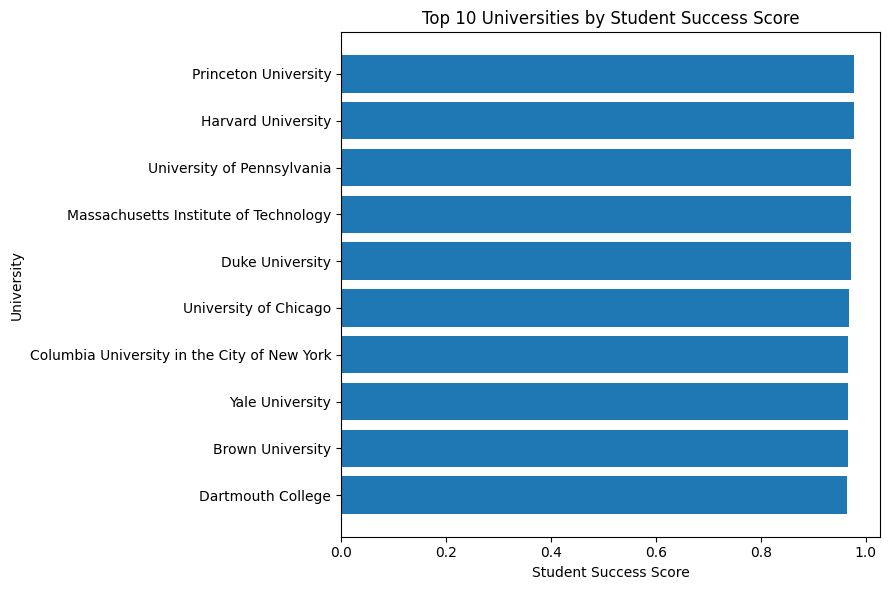

In [26]:
top_success = (
    df[['INSTNM', 'STUDENT_SUCCESS']]
    .dropna()
    .sort_values('STUDENT_SUCCESS', ascending=False)
    .head(10)
    .sort_values('STUDENT_SUCCESS')
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_success['INSTNM'],
    top_success['STUDENT_SUCCESS']
)

plt.xlabel('Student Success Score')
plt.ylabel('University')
plt.title('Top 10 Universities by Student Success Score')

plt.tight_layout()
plt.show()

**Interpretation:** These institutions have the highest combined graduation and retention performance in the dataset. This shows which universities perform especially well on Student Success before that feature is combined with affordability, outcomes, and accessibility in the final ranking.

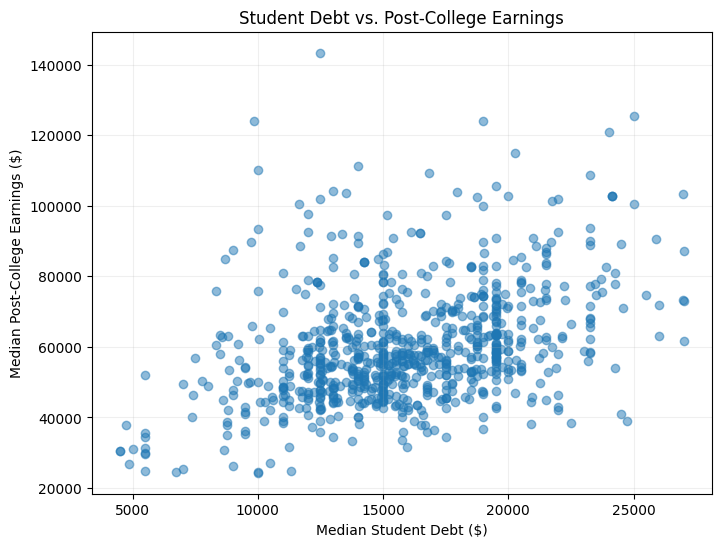

In [27]:
debt_earnings = (
    df[['DEBT_MDN', 'MD_EARN_WNE_P10']]
    .dropna()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    debt_earnings['DEBT_MDN'],
    debt_earnings['MD_EARN_WNE_P10'],
    alpha=0.5
)

plt.xlabel('Median Student Debt ($)')
plt.ylabel('Median Post-College Earnings ($)')
plt.title('Student Debt vs. Post-College Earnings')

plt.grid(alpha=0.2)
plt.show()

**Interpretation:** Universities with higher median student debt often also show higher post-college earnings, but the relationship is not consistent across institutions. Schools with similar debt levels can have very different earnings outcomes, which supports considering both measures rather than using either one alone.

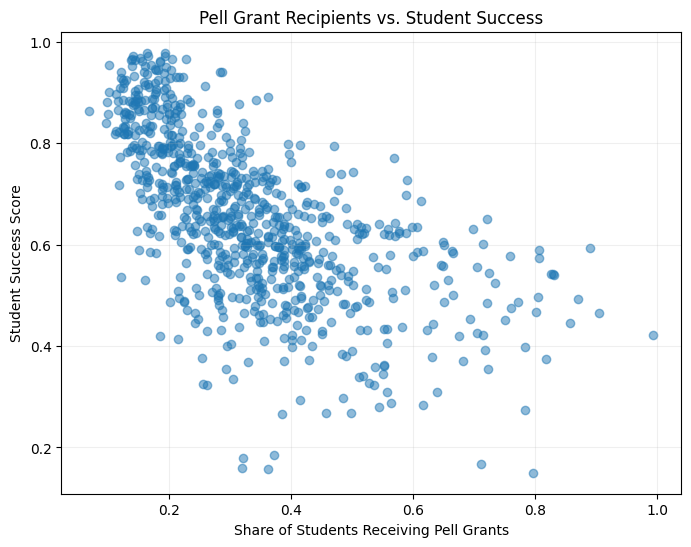

In [28]:
pell_success = (
    df[['PCTPELL', 'STUDENT_SUCCESS']]
    .dropna()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    pell_success['PCTPELL'],
    pell_success['STUDENT_SUCCESS'],
    alpha=0.5
)

plt.xlabel('Share of Students Receiving Pell Grants')
plt.ylabel('Student Success Score')
plt.title('Pell Grant Recipients vs. Student Success')

plt.grid(alpha=0.2)
plt.show()

**Interpretation:** This visualization explores the relationship between socioeconomic accessibility and student success. The pattern should be interpreted cautiously because Pell Grant share captures only one aspect of accessibility and the relationship shown here does not establish causation.